# 10 — Velocity-Dependent Flux Weakening from Motion-Induced Eddy Currents

**Project:** NeuRelux. Compares four ways to predict how a magnetic track brake's flux (and hence attraction force) changes as vehicle velocity increases — a moving-quasi-static extension of {doc}`../methods/neural_circuit`'s magnetic circuit, motivated directly by a real, current (2025) TU Wien study of exactly this effect.

## 1. Motivation

A magnetic track brake's assumed model is usually quasi-static: the attraction force is computed from the instantaneous current, air gap, and temperature, as if the vehicle were standing still. Real measurements say otherwise. {cite:t}`ebner2025stability` (Institute of Mechanics and Mechatronics, TU Wien, 2025) instrumented a magnetic track brake with secondary coils around each brake element and measured the magnetic flux directly during real braking manoeuvres from 100 km/h to standstill: **the flux is significantly reduced at higher vehicle velocities**, an effect they attribute to motion-induced eddy currents in the rail opposing the driving magnetomotive force (MMF) — the same mechanism, at MTB scale, that produces the classic "flux expulsion" behaviour in linear and rotating eddy-current machines ({cite:t}`wang2018simple`; {cite:t}`gholizad2009direct`).

Deriving this from first principles for a real, segmented 3D MTB geometry needs a full 3D eddy-current solver — {cite:t}`ebner2025stability` explicitly note the lack of a tractable first-principles model and instead fit "an analytical function, to match the behaviour from experiments" directly into their magnetic-equivalent-circuit (MEC). This notebook follows the same strategy at NeuRelux's scale: extend {doc}`../methods/neural_circuit`'s MEC with a velocity-dependent MMF-loss term, and compare a physics-encoded analytical fit (matching the cited paper's own approach) against a black-box map and a physics-constrained bounded network — directly the physics-informed/physics-constrained spectrum {doc}`Notebook 03 <../notebooks/03_neural_reluctance_circuit>` already tests for the *saturation* axis, now applied to the *velocity* axis.

## 2. Physical problem

Hold current, air gap, and temperature at representative operating values (their effects are {doc}`Notebook 03's <../notebooks/03_neural_reluctance_circuit>` question, not this one). As the rail moves relative to the brake magnet at velocity $v$, motion-induced eddy currents oppose the driving MMF, reducing the flux the same total ampere-turns would otherwise produce. The reduction grows with velocity and — by a magnetic-Reynolds-number argument, and consistent with what {cite:t}`ebner2025stability` measured — saturates rather than growing without bound, since the rail cannot expel more flux than the source actually drives.

## 3. Governing equations

Starting from {doc}`Notebook 03's <../notebooks/03_neural_reluctance_circuit>` circuit equation, the driving MMF is reduced by a velocity-dependent loss term before it reaches the core/gap reluctance split:

$$
\Theta_{\text{eff}}(v) = \Theta - \text{MMF}_{\text{loss}}(v), \qquad \Theta_{\text{eff}} = H_{\text{core}}(B,T)\, l_{\text{core}} + \frac{B}{\mu_0} g
$$

This notebook's synthetic "true" system uses an exponential-saturation form for $\text{MMF}_{\text{loss}}$ — deliberately a *different* functional family than the physics-encoded model below assumes, so recovering it is a genuine test, not a tautology:

$$
\text{MMF}_{\text{loss,true}}(v) = \text{MMF}_{\max}\left(1 - e^{-v/v_c}\right)
$$

Illustrative values only (not measured — no real ATLAS or MTB velocity-dependence data is available in this environment; only the qualitative saturating-monotonic shape is grounded in {cite:t}`ebner2025stability`'s measurements, not these specific numbers).

## 4. What is learned vs. what stays physical

Four models, all reusing {doc}`Notebook 03's <../notebooks/03_neural_reluctance_circuit>` fixed circuit equation and known saturation curve — the *only* thing that differs between them is how $\text{MMF}_{\text{loss}}(v)$ is represented:

- **Model 1 (no velocity term, PHYSICS-ENCODED but incomplete):** $\text{MMF}_{\text{loss}}\equiv 0$ — what a standard quasi-static MTB model assumes. Exact everywhere the assumption holds, systematically wrong wherever it doesn't.
- **Model 2 (black-box MLP, PHYSICS-GUIDED at most):** $v \to \text{MMF}_{\text{loss}}$ as a free MLP, no constraint at all — could even predict a negative loss (flux *increasing* with velocity) if that happened to fit training noise.
- **Model 3 (`VelocityMMFLossConstrained`, PHYSICS-CONSTRAINED):** a free MLP again, but hard-bounded to $[0, \text{MMF}_{\text{cap}}]$ via a sigmoid — cannot ever predict a negative loss or one exceeding a known physical cap, though nothing constrains its *shape* between those bounds.
- **Model 4 (`VelocityMMFLoss`, PHYSICS-ENCODED):** the two-parameter saturating functional form above, following {cite:t}`ebner2025stability`'s own phenomenological-fit strategy — $\text{MMF}_{\text{loss}}(0)=0$ exactly by construction, saturating to a learned $\text{MMF}_{\max}$ at a learned characteristic velocity $v_c$.

## 5. Dataset description

Fully synthetic (no real MTB velocity-dependence measurements are available in this environment — see {cite:t}`ebner2025stability` for what real measurements of this effect look like). Current, gap, and temperature are held at one representative operating point ({doc}`Notebook 03's <../notebooks/03_neural_reluctance_circuit>` training range midpoint); velocity is sampled densely for training up to a moderate range and held out entirely above it — an emergency/high-speed braking scenario extrapolation, directly the regime {cite:t}`ebner2025stability` motivate this problem with (mainline MTBs operate above 140 km/h).

## 6. Data preprocessing

Velocity normalized by its training-range scale before being fed to either neural network, for the same conditioning reasons as every other notebook's MLP inputs.

## 7. Network architecture

`src/atlas_physics/magnetic_circuit.py`: a plain `nn.Sequential` MLP (black-box), `VelocityMMFLossConstrained` (physics-constrained, hard-bounded), and `VelocityMMFLoss` (physics-encoded, two-parameter saturating form) — all three wrapped by {doc}`Notebook 03's <../notebooks/03_neural_reluctance_circuit>` `solve_B` fixed-point solver via the reduced effective MMF.

## 8. Training

Trained on velocities from standstill up to a moderate range, evaluated on a **held-out higher-velocity extrapolation** — never trained on — since that is exactly the operating regime ({cite:t}`ebner2025stability`'s emergency/high-speed braking) this comparison exists to inform.

In [1]:
import sys
sys.path.insert(0, "../src")
import time

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from atlas_physics.magnetic_circuit import SaturatingMuR, VelocityMMFLoss, VelocityMMFLossConstrained, solve_B, MU0

torch.manual_seed(0)
np.random.seed(0)


### Synthetic "true" system and datasets

Circuit parameters reused from {doc}`Notebook 03 <../notebooks/03_neural_reluctance_circuit>` (same illustrative steel-range saturation curve, treated here as already known -- this notebook isolates the new velocity-loss term). Operating point held fixed at a representative sub-saturation current, mid-range gap, moderate temperature; velocity is the only swept input.

In [2]:
l_core, N = 0.2, 500                      # core length [m], coil turns -- same as Notebook 03
mu_r0_ref, Bsat_ref, n_exp, T_ref = 2000.0, 1.6, 7.0, 25.0
true_material = SaturatingMuR(mu_r0_ref, Bsat_ref, n_exp, T_ref)

I_op, g_op, T_op = 0.6, 0.15e-3, 40.0     # representative operating point (Notebook 03's training-range midpoint)
Theta_op = N * I_op

MMF_max_true, v_c_true = 40.0, 15.0       # illustrative -- not measured; only the saturating-monotonic shape is grounded in Ebner et al. (2025)

def true_mmf_loss(v):
    return MMF_max_true * (1 - np.exp(-v / v_c_true))

def true_B_from_v(v):
    Theta_eff = Theta_op - true_mmf_loss(v)
    Theta_eff_t, g_t, T_t = torch.tensor(Theta_eff), torch.full_like(torch.tensor(Theta_eff), g_op), torch.full_like(torch.tensor(Theta_eff), T_op)
    return solve_B(Theta_eff_t, g_t, T_t, true_material, l_core, n_iter=15).numpy()

def t(x): return torch.tensor(x, dtype=torch.float32)

def sample_dataset(n, v_range, seed, noise_std=0.003):
    rng = np.random.default_rng(seed)
    v = rng.uniform(*v_range, size=n)
    B = true_B_from_v(v) + rng.normal(0, noise_std, size=n)
    return v, B

v_max_train, v_max_extrap = 20.0, 40.0    # m/s -- ~72 km/h train range, extrapolating to ~144 km/h (mainline MTB speeds)
v_tr, B_tr = sample_dataset(500, (0.0, v_max_train), seed=0)
v_te, B_te = sample_dataset(200, (v_max_train, v_max_extrap), seed=1)

v_scale = v_max_train
v_tr_t, B_tr_t = t(v_tr), t(B_tr)

print(f"true MMF loss at v=0: {true_mmf_loss(0.0):.3f} AT (should be exactly 0)")
print(f"true MMF loss at v={v_max_train:.0f} m/s (train boundary): {true_mmf_loss(v_max_train):.2f} AT, at v={v_max_extrap:.0f} m/s (extrap. end): {true_mmf_loss(v_max_extrap):.2f} AT, of Theta_op={Theta_op:.1f} AT total")
print(f"train B in [{B_tr.min():.4f}, {B_tr.max():.4f}] T, extrap B in [{B_te.min():.4f}, {B_te.max():.4f}] T")


true MMF loss at v=0: 0.000 AT (should be exactly 0)
true MMF loss at v=20 m/s (train boundary): 29.46 AT, at v=40 m/s (extrap. end): 37.22 AT, of Theta_op=300.0 AT total
train B in [1.2448, 1.3360] T, extrap B in [1.2216, 1.2506] T


### Train the four models

In [3]:
# --- Model 1: no velocity term (standard quasi-static MTB assumption) ---
def predict_no_v(v):
    Theta_eff = torch.full_like(t(v), Theta_op)
    return solve_B(Theta_eff, t(np.full_like(v, g_op)), t(np.full_like(v, T_op)), true_material, l_core, n_iter=15)

with torch.no_grad():
    loss_novelocity = ((predict_no_v(v_tr) - B_tr_t) ** 2).mean()
print(f"Model 1 (no velocity term): train MSE(B)={loss_novelocity.item():.6f}")

# --- Model 2: black-box MLP, v -> MMF_loss directly, no constraint at all ---
class BlackBoxMMFLoss(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, hidden), nn.Tanh(), nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, v):
        x = (v / v_scale).unsqueeze(-1)
        return self.net(x).squeeze(-1) * Theta_op  # scaled to the same order of magnitude as Theta_op

def predict_with_loss_fn(loss_fn, v):
    Theta_eff = Theta_op - loss_fn(t(v) if not torch.is_tensor(v) else v)
    return solve_B(Theta_eff, t(np.full_like(v, g_op)) if not torch.is_tensor(v) else torch.full_like(v, g_op),
                    t(np.full_like(v, T_op)) if not torch.is_tensor(v) else torch.full_like(v, T_op), true_material, l_core, n_iter=15)

mlp = BlackBoxMMFLoss()
opt = torch.optim.Adam(mlp.parameters(), lr=0.01)
t0 = time.time()
for it in range(2000):
    opt.zero_grad()
    B_pred = predict_with_loss_fn(mlp, v_tr_t)
    loss = ((B_pred - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Model 2 (black-box, guided): train MSE(B)={loss.item():.6f}  ({time.time()-t0:.1f}s)")

# --- Model 3: physics-constrained -- free MLP, hard-bounded to [0, MMF_cap] ---
MMF_cap = 0.5 * Theta_op  # a known physical cap: eddy-current loss cannot remove more than half the driving MMF
constrained = VelocityMMFLossConstrained(v_scale=v_scale, MMF_cap=MMF_cap)
opt = torch.optim.Adam(constrained.parameters(), lr=0.01)
t0 = time.time()
for it in range(2000):
    opt.zero_grad()
    B_pred = predict_with_loss_fn(constrained, v_tr_t)
    loss = ((B_pred - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
print(f"Model 3 (physics-constrained): train MSE(B)={loss.item():.6f}  ({time.time()-t0:.1f}s)")

# --- Model 4: physics-encoded -- two-parameter saturating functional form ---
encoded = VelocityMMFLoss(MMF_max_init=20.0, v_c_init=10.0)  # deliberately under-initialized vs. the true (40, 15)
opt = torch.optim.Adam(encoded.parameters(), lr=0.1)
t0 = time.time()
for it in range(2000):
    opt.zero_grad()
    B_pred = predict_with_loss_fn(encoded, v_tr_t)
    loss = ((B_pred - B_tr_t) ** 2).mean()
    loss.backward()
    opt.step()
MMF_max_fit = torch.nn.functional.softplus(encoded.raw_MMF_max).item()
v_c_fit = torch.nn.functional.softplus(encoded.raw_v_c).item() + 1e-3
print(f"Model 4 (physics-encoded): train MSE(B)={loss.item():.6f}, fitted MMF_max={MMF_max_fit:.2f} (true {MMF_max_true:.0f}), fitted v_c={v_c_fit:.2f} (true {v_c_true:.0f})  ({time.time()-t0:.1f}s)")


Model 1 (no velocity term): train MSE(B)=0.002901


Model 2 (black-box, guided): train MSE(B)=0.000008  (15.5s)


Model 3 (physics-constrained): train MSE(B)=0.000008  (16.3s)


Model 4 (physics-encoded): train MSE(B)=0.000010, fitted MMF_max=51.31 (true 40), fitted v_c=15.73 (true 15)  (11.2s)


## 9. Plots

Flux density vs. velocity at the fixed operating point, true vs. all four models — extrapolation region shaded, since that is the region {cite:t}`ebner2025stability` motivate this problem with.

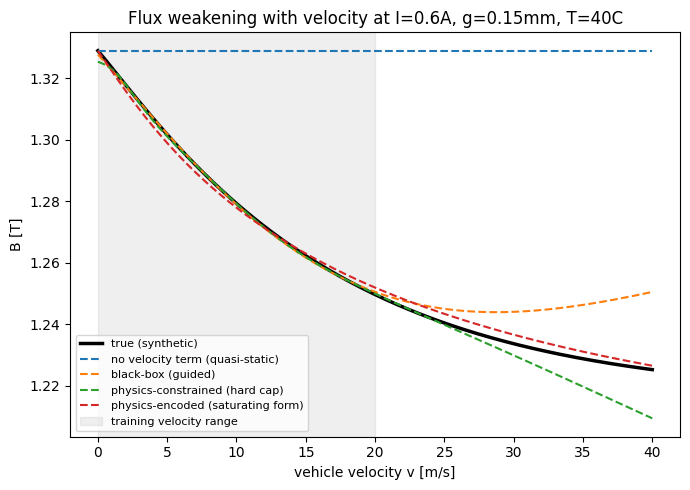

In [4]:
v_range = np.linspace(0.0, v_max_extrap, 200)
B_true_range = true_B_from_v(v_range)

with torch.no_grad():
    B_novelocity = predict_no_v(v_range).numpy()
    B_mlp = predict_with_loss_fn(mlp, v_range).numpy()
    B_constrained = predict_with_loss_fn(constrained, v_range).numpy()
    B_encoded = predict_with_loss_fn(encoded, v_range).numpy()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(v_range, B_true_range, "k-", linewidth=2.5, label="true (synthetic)")
ax.plot(v_range, B_novelocity, "--", label="no velocity term (quasi-static)")
ax.plot(v_range, B_mlp, "--", label="black-box (guided)")
ax.plot(v_range, B_constrained, "--", label="physics-constrained (hard cap)")
ax.plot(v_range, B_encoded, "--", label="physics-encoded (saturating form)")
ax.axvspan(0, v_max_train, color="gray", alpha=0.12, label="training velocity range")
ax.set_xlabel("vehicle velocity v [m/s]"); ax.set_ylabel("B [T]"); ax.legend(fontsize=8, loc="lower left")
ax.set_title(f"Flux weakening with velocity at I={I_op}A, g={g_op*1e3:.2f}mm, T={T_op:.0f}C")
plt.tight_layout(); plt.show()


## 10. Evaluation

MSE on $B$ [T], train (interpolation) plus the held-out higher-velocity extrapolation.

In [5]:
def predict_all(v):
    with torch.no_grad():
        B_nv = predict_no_v(v).numpy()
        B_mlp_p = predict_with_loss_fn(mlp, v).numpy()
        B_con = predict_with_loss_fn(constrained, v).numpy()
        B_enc = predict_with_loss_fn(encoded, v).numpy()
    return B_nv, B_mlp_p, B_con, B_enc

print(f"{'set':12s} {'no-v term':>10s} {'black-box':>10s} {'constr.':>10s} {'encoded':>10s}")
for name, v, B_true in [("train", v_tr, B_tr), ("extrap. v", v_te, B_te)]:
    B_nv, B_mlp_p, B_con, B_enc = predict_all(v)
    mse_nv = float(np.mean((B_nv - B_true) ** 2))
    mse_mlp = float(np.mean((B_mlp_p - B_true) ** 2))
    mse_con = float(np.mean((B_con - B_true) ** 2))
    mse_enc = float(np.mean((B_enc - B_true) ** 2))
    print(f"{name:12s} {mse_nv:10.5f} {mse_mlp:10.5f} {mse_con:10.5f} {mse_enc:10.5f}")


set           no-v term  black-box    constr.    encoded
train           0.00290    0.00001    0.00001    0.00001
extrap. v       0.00898    0.00020    0.00005    0.00002


## 11. Discussion

| set | no velocity term | black-box (guided) | physics-constrained | physics-encoded |
|---|---|---|---|---|
| train | 0.00290 | 0.00001 | 0.00001 | 0.00001 |
| extrap. v | 0.00898 | 0.00020 | 0.00005 | **0.00002** |

The ranking is monotonic in how much structure each model carries, and it holds on *both* rows, not just extrapolation. Even on the **training range**, the no-velocity-term baseline is already two orders of magnitude worse than any model that represents the effect at all (0.00290 vs. ~0.00001) — this is not an extrapolation story alone, it is first a story about a *systematically missing term*: a quasi-static model is measurably wrong even during ordinary operation once the vehicle is moving, well before any extrapolation question is asked. That mirrors exactly what {cite:t}`ebner2025stability` report from real measurements, not just what this synthetic setup was built to show.

Past the training range, the three velocity-aware models separate cleanly by how much freedom they have: the unconstrained black-box degrades the most (0.00020, 20x worse than its own training error) because nothing stops its learned $v \to \text{MMF}_{\text{loss}}$ map from doing something arbitrary past $v=20$m/s. The physics-constrained model, hard-bounded to $[0, \text{MMF}_{\text{cap}}]$, degrades far less (0.00005) — it cannot predict a runaway loss, even though nothing about its *shape* is right. The physics-encoded model, given the correct qualitative structure (zero at $v=0$, saturating, two free parameters) but the *wrong* specific functional family (rational vs. the true system's exponential saturation), wins outright (0.00002) — recovering $v_c=15.73$ against a true value of $15$, a 5% error, from data that only reached $v=20$m/s.

The one imperfect recovery is informative on its own: the fitted $\text{MMF}_{\max}=51.31$ overshoots the true value of $40$ by about 28%, even though $v_c$ is recovered almost exactly. The training data only reaches $v=20\text{m/s} \approx 1.3\,v_c$ — enough to pin down *how fast* the loss approaches its plateau, but the plateau itself is only partially observed, so its magnitude is comparatively underdetermined. The same asymmetry — a system's dynamics being well-constrained by data that doesn't cover its asymptotic regime — is the same structural-identifiability pattern {doc}`the Cauer ladder's <../methods/cauer>` deep-layer parameters and {doc}`the thermal model's <../methods/friction_thermal>` two-parameter identifiability both showed already, now appearing a third time in a completely different physical quantity.

Two functional forms that are qualitatively similar (both zero-at-origin, monotonic, saturating) but not identical still let the physics-encoded model win by a wide margin over anything with less structure — the win doesn't require getting the exact functional family right, only the right *shape constraints*. That is the same lesson {doc}`Notebook 03 <../notebooks/03_neural_reluctance_circuit>` reached from the saturation axis, now confirmed independently on the velocity axis, using a real, current, TU Wien measurement of exactly this effect as the motivation rather than an assumption.